# 🍽️ Train Food Segmentation Model on FoodSeg103

This notebook trains a semantic segmentation model on the [FoodSeg103 dataset](https://huggingface.co/datasets/EduardoPacheco/FoodSeg103) from HuggingFace.

The trained model can be combined with SAM3 for the **FoodSAM** approach:
- SAM3 generates high-quality, category-agnostic masks
- This model provides specific food labels (104 classes)
- Mask-category matching assigns labels to SAM masks

## Contents
1. [Setup & Installation](#1-setup--installation)
2. [Load Dataset](#2-load-dataset)
3. [Explore Data](#3-explore-data)
4. [Prepare DataLoaders](#4-prepare-dataloaders)
5. [Create Model](#5-create-model)
6. [Training](#6-training)
7. [Evaluation](#7-evaluation)
8. [Save & Export](#8-save--export)
9. [Integration with SAM3](#9-integration-with-sam3)

---
## 🎯 Fine-tuning SAM3 for Food Segmentation

There are **two approaches** to get accurate food semantic segmentation with SAM3:

### Approach 1: FoodSAM (Current Notebook) ✅ Recommended
- **Train a separate semantic segmentation model** (DeepLabV3+) on FoodSeg103
- **Use SAM3 for high-quality masks** (category-agnostic)
- **Combine them**: Match SAM3 masks with semantic labels
- **Pros**: Simpler, works without modifying SAM3, lower GPU requirements
- **Cons**: Two-model pipeline, potential label mismatches

### Approach 2: Direct SAM3 Fine-tuning 
- **Fine-tune SAM3's detector** on FoodSeg103 with text prompts
- SAM3 learns to respond to prompts like "rice", "broccoli", etc.
- **Pros**: Single unified model, leverages SAM3's segmentation quality
- **Cons**: Requires converting data to COCO format, more GPU memory, longer training

---

## Direct SAM3 Fine-tuning Guide

SAM3 supports fine-tuning on custom datasets using the training infrastructure in `sam3/train/`. Here's how to do it:

### Prerequisites
```bash
pip install -e ".[train]"  # Install training dependencies
```

### Step 1: Convert FoodSeg103 to COCO Format

SAM3 expects annotations in **COCO JSON format** with text queries (category names as prompts).

### Step 2: Create Training Configuration

Create a YAML config file based on existing configs in `sam3/train/configs/`.

### Step 3: Run Training
```bash
python sam3/train/train.py -c configs/your_foodseg_config.yaml --use-cluster 0 --num-gpus 1
```

The cells below show both approaches in detail.

---
## 1. Setup & Installation

In [1]:
# Install required packages
!pip install -q datasets torch torchvision segmentation-models-pytorch albumentations tqdm pillow matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires torch<2.9,>=1.10, but you have torch 2.10.0.dev20251204+cu128 which is incompatible.
sam3 0.1.0 requires numpy==1.26, but you have numpy 2.2.6 which is incompatible.


In [1]:
import numpy as np
print(f"NumPy version: {np.__version__}")

# Test SAM3 still works
from sam3.model_builder import build_sam3_image_model
model = build_sam3_image_model()
print("✅ SAM3 loads fine!")

NumPy version: 2.2.6
✅ SAM3 loads fine!


In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Memory: 17.1 GB


In [2]:
# FoodSeg103 class names (104 classes: 0=background + 103 food categories)
FOODSEG103_CLASSES = [
    "background", "candy", "egg tart", "french fries", "chocolate",
    "biscuit", "popcorn", "pudding", "ice cream", "cheese butter",
    "cake", "wine", "milkshake", "coffee", "juice", "milk", "tea",
    "almond", "red beans", "cashew", "dried cranberries", "soy",
    "walnut", "peanut", "egg", "apple", "date", "apricot", "avocado",
    "banana", "strawberry", "cherry", "blueberry", "raspberry", "mango",
    "olives", "peach", "lemon", "pear", "fig", "pineapple", "grape",
    "kiwi", "melon", "orange", "watermelon", "steak", "pork", "chicken duck",
    "sausage", "fried meat", "lamb", "sauce", "crab", "fish", "shellfish",
    "shrimp", "soup", "bread", "corn", "hamburg", "pizza", "hanamaki baozi",
    "wonton dumplings", "pasta", "noodles", "rice", "pie", "tofu", "eggplant",
    "potato", "garlic", "cauliflower", "tomato", "kelp", "seaweed",
    "spring onion", "rape", "ginger", "okra", "lettuce", "pumpkin",
    "cucumber", "white radish", "carrot", "asparagus", "bamboo shoots",
    "broccoli", "celery stick", "cilantro mint", "snow peas", "cabbage",
    "bean sprouts", "onion", "pepper", "green beans", "French beans",
    "king oyster mushroom", "shiitake", "enoki mushroom", "oyster mushroom",
    "white button mushroom", "salad", "other ingredients"
]

NUM_CLASSES = len(FOODSEG103_CLASSES)
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 104


---
## 2. Load Dataset

In [3]:
from datasets import load_dataset

# Load FoodSeg103 from HuggingFace
print("Loading FoodSeg103 dataset from HuggingFace...")
dataset = load_dataset("EduardoPacheco/FoodSeg103")

print(f"\n✅ Dataset loaded!")
print(f"  Train: {len(dataset['train'])} images")
print(f"  Validation: {len(dataset['validation'])} images")

Loading FoodSeg103 dataset from HuggingFace...

✅ Dataset loaded!
  Train: 4983 images
  Validation: 2135 images


In [4]:
# Check dataset structure
print("Dataset features:")
print(dataset['train'].features)

print("\nSample item keys:")
sample = dataset['train'][0]
for key, value in sample.items():
    if isinstance(value, Image.Image):
        print(f"  {key}: PIL Image {value.size}")
    else:
        print(f"  {key}: {type(value).__name__} = {value}")

Dataset features:
{'image': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True), 'classes_on_image': List(Value('int64')), 'id': Value('int64')}

Sample item keys:
  image: PIL Image (512, 384)
  label: PIL Image (512, 384)
  classes_on_image: list = [0, 48, 66, 90]
  id: int = 0


---
## 3. Explore Data

In [5]:
def visualize_sample(sample, class_names=FOODSEG103_CLASSES):
    """Visualize a single sample with its segmentation mask."""
    image = sample['image']
    label = sample['label']
    classes_on_image = sample['classes_on_image']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Segmentation mask
    axes[1].imshow(label)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    
    # Overlay
    img_array = np.array(image)
    mask_array = np.array(label)
    
    # Create colored overlay
    np.random.seed(42)
    colors = np.random.randint(0, 255, (NUM_CLASSES, 3))
    colors[0] = [0, 0, 0]  # Background is black
    
    colored_mask = colors[mask_array]
    overlay = (0.6 * img_array + 0.4 * colored_mask).astype(np.uint8)
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    # Print classes present
    present_classes = [class_names[i] for i in classes_on_image if i < len(class_names)]
    print(f"Classes in image: {present_classes}")
    
    plt.tight_layout()
    plt.show()


--- Sample 0 ---
Classes in image: ['background', 'chicken duck', 'rice', 'snow peas']


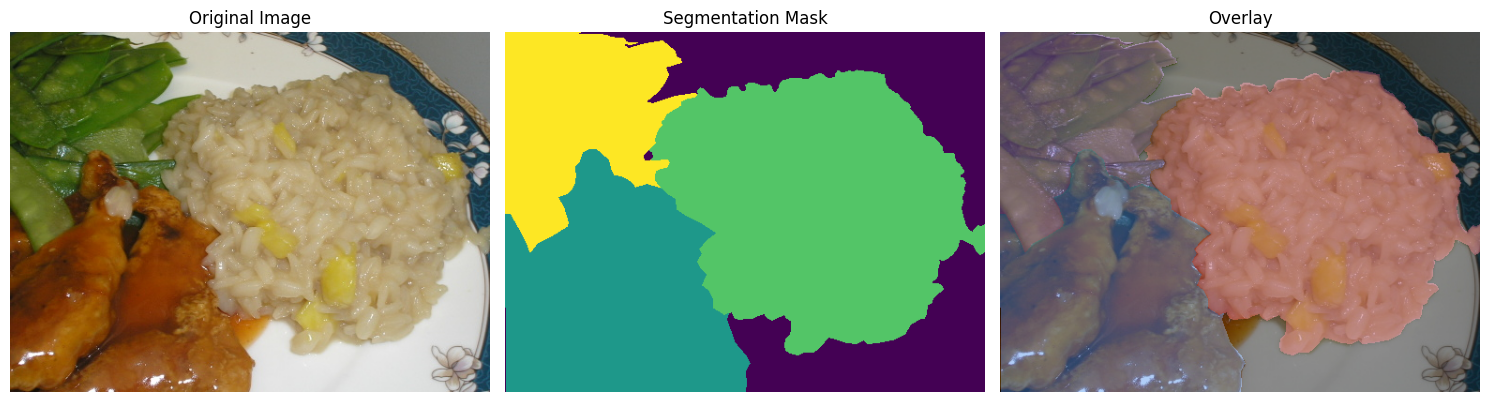


--- Sample 100 ---
Classes in image: ['background', 'pork', 'sauce', 'potato', 'tomato', 'carrot']


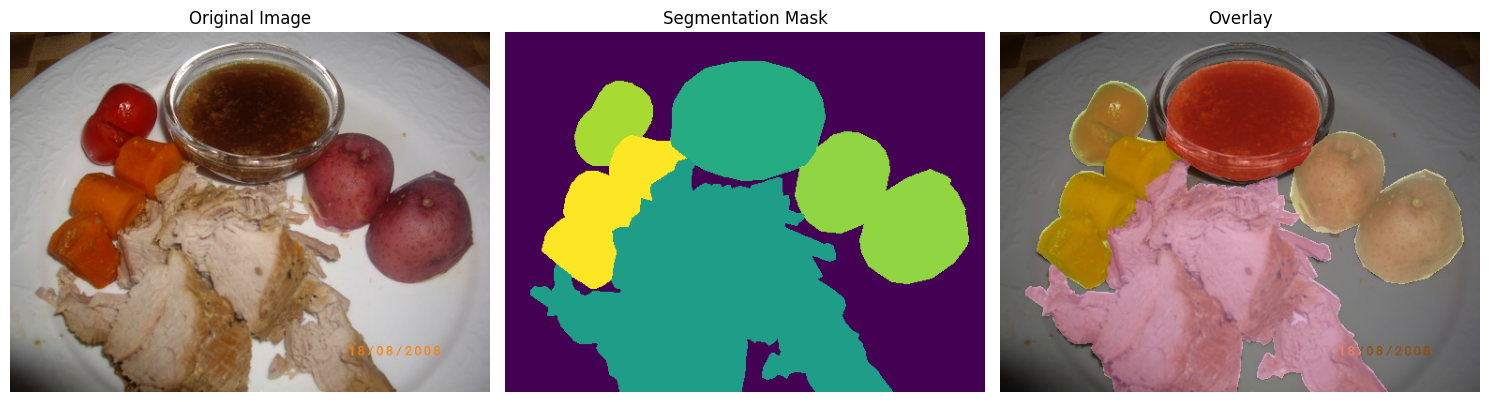


--- Sample 500 ---
Classes in image: ['background', 'lettuce', 'other ingredients']


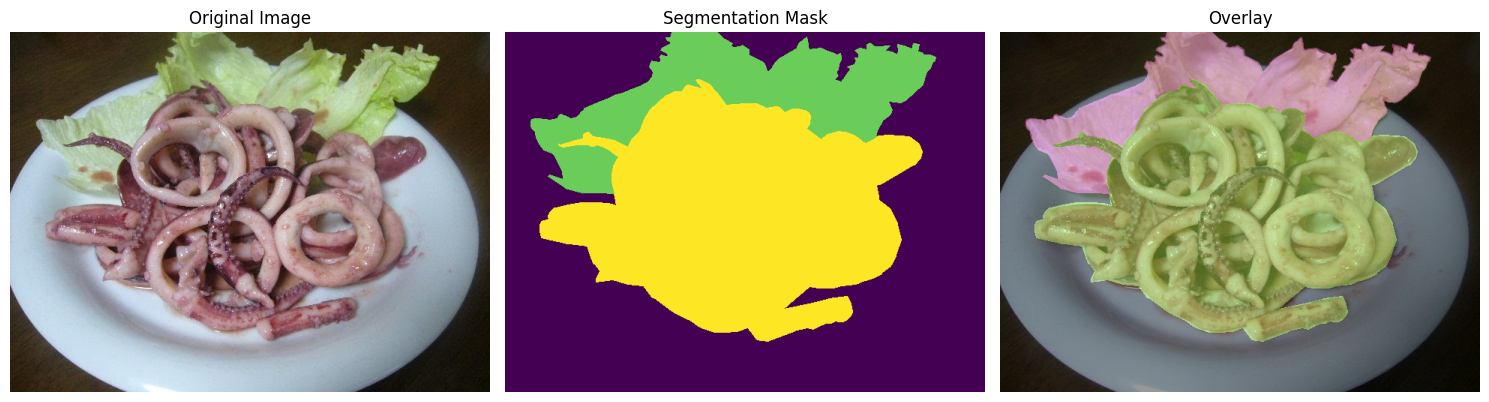

In [6]:
# Visualize a few samples
for i in [0, 100, 500]:
    print(f"\n--- Sample {i} ---")
    visualize_sample(dataset['train'][i])

In [7]:
# Class distribution analysis
from collections import Counter

print("Analyzing class distribution...")
class_counts = Counter()

for sample in tqdm(dataset['train'], desc="Counting classes"):
    for cls in sample['classes_on_image']:
        class_counts[cls] += 1

# Top 20 most common classes
print("\nTop 20 most common classes:")
for cls_id, count in class_counts.most_common(20):
    cls_name = FOODSEG103_CLASSES[cls_id] if cls_id < len(FOODSEG103_CLASSES) else f"class_{cls_id}"
    print(f"  {cls_id:3d} {cls_name:25s}: {count:4d} images")

Analyzing class distribution...


Counting classes:   0%|          | 0/4983 [00:00<?, ?it/s]


Top 20 most common classes:
    0 background               : 4982 images
   58 bread                    :  991 images
   84 carrot                   :  881 images
   48 chicken duck             :  848 images
   52 sauce                    :  818 images
   73 tomato                   :  790 images
   70 potato                   :  785 images
   46 steak                    :  728 images
   87 broccoli                 :  704 images
   89 cilantro mint            :  636 images
    8 ice cream                :  636 images
   47 pork                     :  474 images
   66 rice                     :  464 images
   37 lemon                    :  423 images
   80 lettuce                  :  403 images
   67 pie                      :  397 images
   30 strawberry               :  388 images
   93 onion                    :  374 images
   82 cucumber                 :  369 images
   59 corn                     :  343 images


---
## 4. Prepare DataLoaders

In [8]:
import albumentations as A

# Configuration
# NOTE: Dimensions should be divisible by 32 for DeepLabV3+
IMG_WIDTH = 512   # 512 / 32 = 16 ✓
IMG_HEIGHT = 384  # 384 / 32 = 12 ✓
BATCH_SIZE = 8    # Reduce if OOM
NUM_WORKERS = 4

In [9]:
class FoodSeg103Dataset(torch.utils.data.Dataset):
    """PyTorch Dataset wrapper for HuggingFace FoodSeg103 dataset."""
    
    def __init__(self, hf_dataset, transform=None, img_width=512, img_height=384):
        self.dataset = hf_dataset
        self.transform = transform
        self.img_width = img_width
        self.img_height = img_height
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        
        # Get image and label
        image = np.array(item['image'].convert('RGB'))
        label = np.array(item['label'])
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=label)
            image = augmented['image']
            label = augmented['mask']
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        label = torch.from_numpy(label).long()
        
        return image, label

In [10]:
# Define augmentations
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),  # height, width
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.Rotate(limit=15, p=0.3),
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),  # height, width
])

/tmp/ipykernel_89702/3598263973.py:7: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


In [11]:
# Create datasets
train_dataset = FoodSeg103Dataset(dataset['train'], transform=train_transform, img_width=IMG_WIDTH, img_height=IMG_HEIGHT)
val_dataset = FoodSeg103Dataset(dataset['validation'], transform=val_transform, img_width=IMG_WIDTH, img_height=IMG_HEIGHT)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")

Train dataset: 4983 samples
Val dataset: 2135 samples


In [12]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 622
Val batches: 267


In [13]:
# Verify dataloader output
images, masks = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")
print(f"Batch masks shape: {masks.shape}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Mask unique values: {torch.unique(masks).tolist()[:10]}... (showing first 10)")

Batch images shape: torch.Size([8, 3, 384, 512])
Batch masks shape: torch.Size([8, 384, 512])
Image value range: [0.000, 1.000]
Mask unique values: [0, 5, 14, 17, 24, 37, 44, 46, 48, 52]... (showing first 10)


---
## 5. Create Model

In [14]:
import segmentation_models_pytorch as smp

# Model configuration
MODEL_NAME = 'MiT'  # Options: 'deeplabv3plus', 'unet', 'fpn', 'pspnet', 'manet'
ENCODER = 'mit_b3'  # Options: 'resnet101', 'efficientnet-b4', 'mit_b3', etc.

print(f"Creating {MODEL_NAME} with {ENCODER} encoder...")

Creating MiT with mit_b3 encoder...


In [15]:
# Create model
model = smp.DeepLabV3Plus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model created!")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


✅ Model created!
  Total parameters: 45,251,384
  Trainable parameters: 45,251,384


In [16]:
# Test forward pass (use eval mode to avoid BatchNorm issues with single sample)
model.eval()
with torch.no_grad():
    test_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).to(device)
    test_output = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    print(f"Output classes: {test_output.shape[1]}")
model.train()  # Set back to train mode

Input shape: torch.Size([1, 3, 384, 512])
Output shape: torch.Size([1, 104, 384, 512])
Output classes: 104


DeepLabV3Plus(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          

---
## 6. Training

In [17]:
# Training configuration
EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Output directory
OUTPUT_DIR = f'./foodseg_checkpoints/{MODEL_NAME}_{ENCODER}_{EPOCHS}epochs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Output directory: {OUTPUT_DIR}")

Training configuration:
  Epochs: 100
  Learning rate: 0.0001
  Weight decay: 0.0001
  Output directory: ./foodseg_checkpoints/MiT_mit_b3_100epochs


In [18]:
import segmentation_models_pytorch as smp

# Loss function - Combined Dice + CE (better for segmentation)
dice_loss = smp.losses.DiceLoss(mode='multiclass', ignore_index=255)
ce_loss = nn.CrossEntropyLoss(ignore_index=255)

def criterion(pred, target):
    return 0.5 * dice_loss(pred, target) + 0.5 * ce_loss(pred, target)

# Optimizer with differential learning rates
optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.1},
    {'params': model.decoder.parameters(), 'lr': LEARNING_RATE},
    {'params': model.segmentation_head.parameters(), 'lr': LEARNING_RATE},
], weight_decay=WEIGHT_DECAY)

# OneCycleLR scheduler (call after each batch)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LEARNING_RATE * 0.1, LEARNING_RATE, LEARNING_RATE],
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,  # 5% warmup
)

print("✅ Improved optimizer and scheduler ready")

✅ Improved optimizer and scheduler ready


In [19]:
def calculate_miou(pred, target, num_classes=NUM_CLASSES, ignore_index=255):
    """Calculate mean Intersection over Union."""
    pred = pred.view(-1)
    target = target.view(-1)
    
    # Remove ignored pixels
    mask = target != ignore_index
    pred = pred[mask]
    target = target[mask]
    
    iou_per_class = []
    
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        
        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()
        
        if union > 0:
            iou_per_class.append((intersection / union).item())
    
    return np.mean(iou_per_class) if iou_per_class else 0.0


def evaluate(model, dataloader, device):
    """Evaluate model on validation set."""
    model.eval()
    total_iou = 0
    num_batches = 0
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            
            batch_iou = calculate_miou(preds, masks)
            total_iou += batch_iou
            num_batches += 1
    
    return total_iou / num_batches if num_batches > 0 else 0.0

In [20]:
class EarlyStopping:
    """Stop training when validation metric stops improving."""
    
    def __init__(self, patience=20, min_delta=0.001, mode='max'):
        """
        Args:
            patience: Epochs to wait before stopping
            min_delta: Minimum change to qualify as improvement
            mode: 'max' for metrics like mIoU, 'min' for loss
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, metric):
        if self.mode == 'max':
            score = metric
        else:  # mode == 'min'
            score = -metric
        
        if self.best_score is None:
            # First epoch
            self.best_score = score
            improved = True
        else:
            # Check if improved by at least min_delta
            improved = score > self.best_score + self.min_delta
        
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
        return self.early_stop
    
    def status(self):
        # Convert back to original metric for display
        display_score = self.best_score if self.mode == 'max' else -self.best_score
        return f"EarlyStopping: {self.counter}/{self.patience} (best: {display_score:.4f})"


In [21]:
# Training loop
history = {
    'train_loss': [],
    'val_miou': [],
    'lr': []
}

best_miou = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(
    patience=20,
    min_delta=0.001,
    mode='max'
)

print(f"\n🚀 Starting training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update scheduler after each batch (required for OneCycleLR)
        scheduler.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate average training loss
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation phase
    val_miou = evaluate(model, val_loader, device)
    
    # Record history (get LR from first param group)
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(avg_train_loss)
    history['val_miou'].append(val_miou)
    history['lr'].append(current_lr)
    
    # Log progress
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val mIoU: {val_miou:.4f} | "
          f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_miou > best_miou:
        best_miou = val_miou
        save_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_miou': best_miou,
            'model_name': MODEL_NAME,
            'encoder': ENCODER,
            'num_classes': NUM_CLASSES,
            'img_width': IMG_WIDTH,
            'img_height': IMG_HEIGHT,
            'class_names': FOODSEG103_CLASSES,
        }, save_path)
        print(f"  ✅ Saved best model with mIoU: {best_miou:.4f}")
    
    if early_stopping(val_miou):
        print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}!")
        print(f"   No improvement for {early_stopping.patience} epochs.")
        break
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(OUTPUT_DIR, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'miou': val_miou,
        }, checkpoint_path)
        print(f"  💾 Saved checkpoint")

print(f"\n🎉 Training complete! Best mIoU: {best_miou:.4f}")


🚀 Starting training for 100 epochs...



Epoch 1/100:   0%|          | 0/622 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/267 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 2.2072 | Val mIoU: 0.0269 | LR: 0.000001
  ✅ Saved best model with mIoU: 0.0269


Epoch 2/100:   0%|          | 0/622 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/267 [00:00<?, ?it/s]

Epoch 75/100 | Train Loss: 0.0845 | Val mIoU: 0.3293 | LR: 0.000002


Epoch 76/100:   0%|          | 0/622 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79eec0d45b20>
Traceback (most recent call last):
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1702, in __del__
    self._shutdown_workers()
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1685, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79eec0d45b20>
Traceback (most recent call last):
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1702, in __del__
    self._shutdown_work

KeyboardInterrupt: 

In [23]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'best_model.pth')

if os.path.exists(checkpoint_path):
    print("📂 Loading saved model...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Print info
    print(f"  ✅ Model loaded successfully!")
    print(f"     Epoch: {checkpoint['epoch']}")
    print(f"     Best mIoU: {checkpoint['best_miou']:.4f}")
    print(f"     Encoder: {checkpoint.get('encoder', 'N/A')}")
    
    # Set best_miou variable for rest of notebook
    best_miou = checkpoint['best_miou']
else:
    print(f"❌ No checkpoint found at {checkpoint_path}")
    print("   Run training first or check OUTPUT_DIR path")

📂 Loading saved model...
  ✅ Model loaded successfully!
     Epoch: 69
     Best mIoU: 0.3413
     Encoder: mit_b3


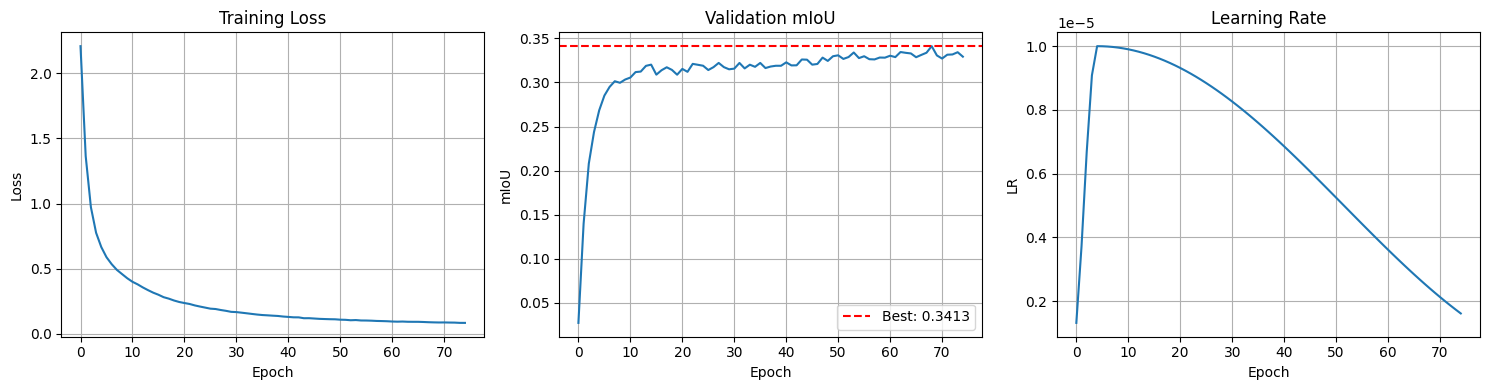

In [24]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss
axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Validation mIoU
axes[1].plot(history['val_miou'])
axes[1].axhline(y=best_miou, color='r', linestyle='--', label=f'Best: {best_miou:.4f}')
axes[1].set_title('Validation mIoU')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU')
axes[1].legend()
axes[1].grid(True)

# Learning rate
axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()

---
## 7. Evaluation

In [25]:
# Load best model
# Note: weights_only=False is safe here since we saved this checkpoint ourselves
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']} with mIoU: {checkpoint['best_miou']:.4f}")

Loaded best model from epoch 69 with mIoU: 0.3413


In [26]:
def visualize_prediction(model, dataset, idx, device, class_names=FOODSEG103_CLASSES):
    """Visualize model prediction on a sample."""
    model.eval()
    
    # Get sample
    image, mask = dataset[idx]
    
    # Predict
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        output = model(image_batch)
        pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
    
    # Convert tensors to numpy for visualization
    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.numpy()
    
    # Create colored masks
    np.random.seed(42)
    colors = np.random.randint(0, 255, (NUM_CLASSES, 3))
    colors[0] = [0, 0, 0]  # Background is black
    
    gt_colored = colors[mask_np]
    pred_colored = colors[pred]
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(image_np)
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    axes[1].imshow(gt_colored)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    axes[2].imshow(pred_colored)
    axes[2].set_title('Prediction')
    axes[2].axis('off')
    
    # Overlay prediction on image
    overlay = (0.6 * (image_np * 255) + 0.4 * pred_colored).astype(np.uint8)
    axes[3].imshow(overlay)
    axes[3].set_title('Prediction Overlay')
    axes[3].axis('off')
    
    # Calculate IoU for this sample
    sample_iou = calculate_miou(
        torch.from_numpy(pred).view(-1),
        mask.view(-1)
    )
    print(f"Sample mIoU: {sample_iou:.4f}")
    
    # Print predicted classes
    pred_classes = np.unique(pred)
    pred_class_names = [class_names[c] for c in pred_classes if c < len(class_names) and c != 0]
    print(f"Predicted classes: {pred_class_names}")
    
    plt.tight_layout()
    plt.show()


--- Validation Sample 0 ---
Sample mIoU: 0.9141
Predicted classes: ['dried cranberries', 'shrimp', 'rice', 'carrot', 'French beans']


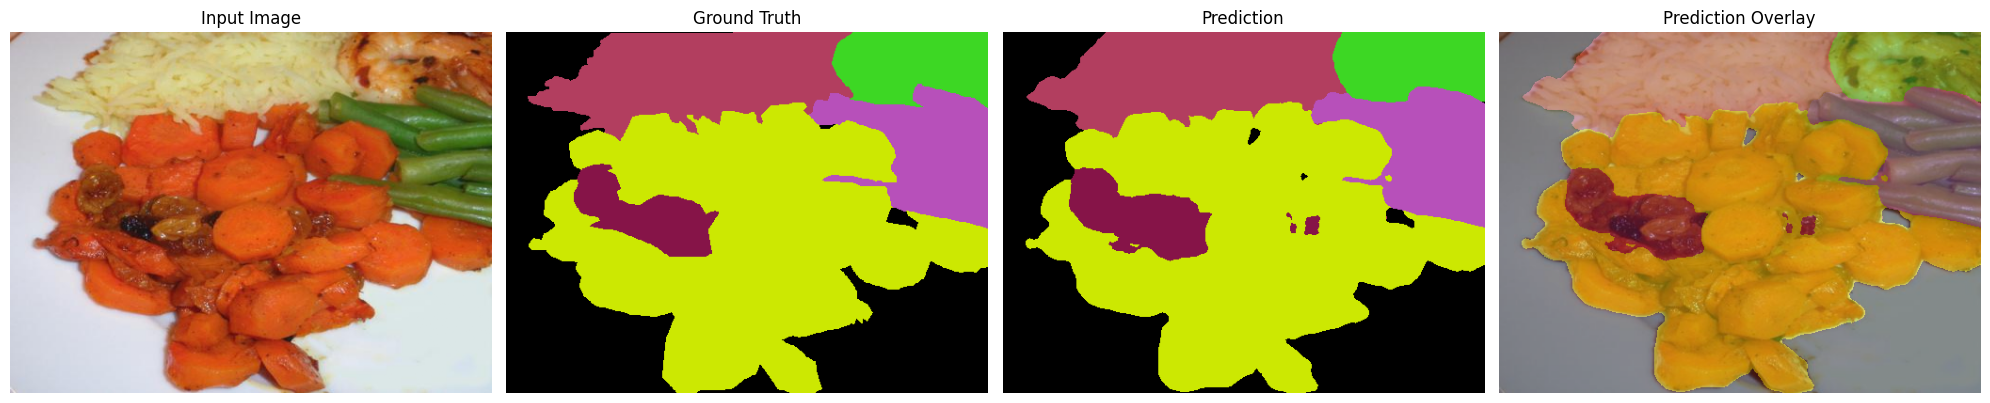


--- Validation Sample 50 ---
Sample mIoU: 0.3693
Predicted classes: ['chicken duck', 'corn', 'rice', 'spring onion', 'carrot', 'broccoli', 'cilantro mint', 'green beans']


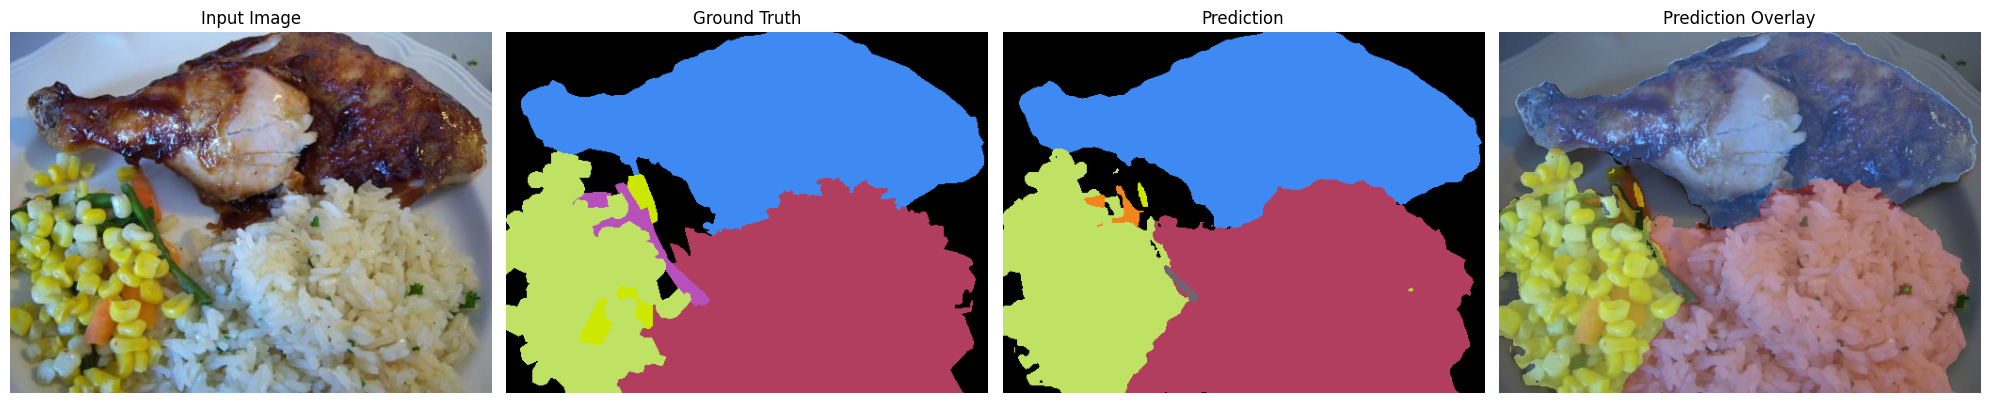


--- Validation Sample 100 ---
Sample mIoU: 0.1889
Predicted classes: ['strawberry', 'cherry', 'blueberry', 'chicken duck', 'sauce', 'fish', 'tomato', 'broccoli', 'cilantro mint', 'pepper']


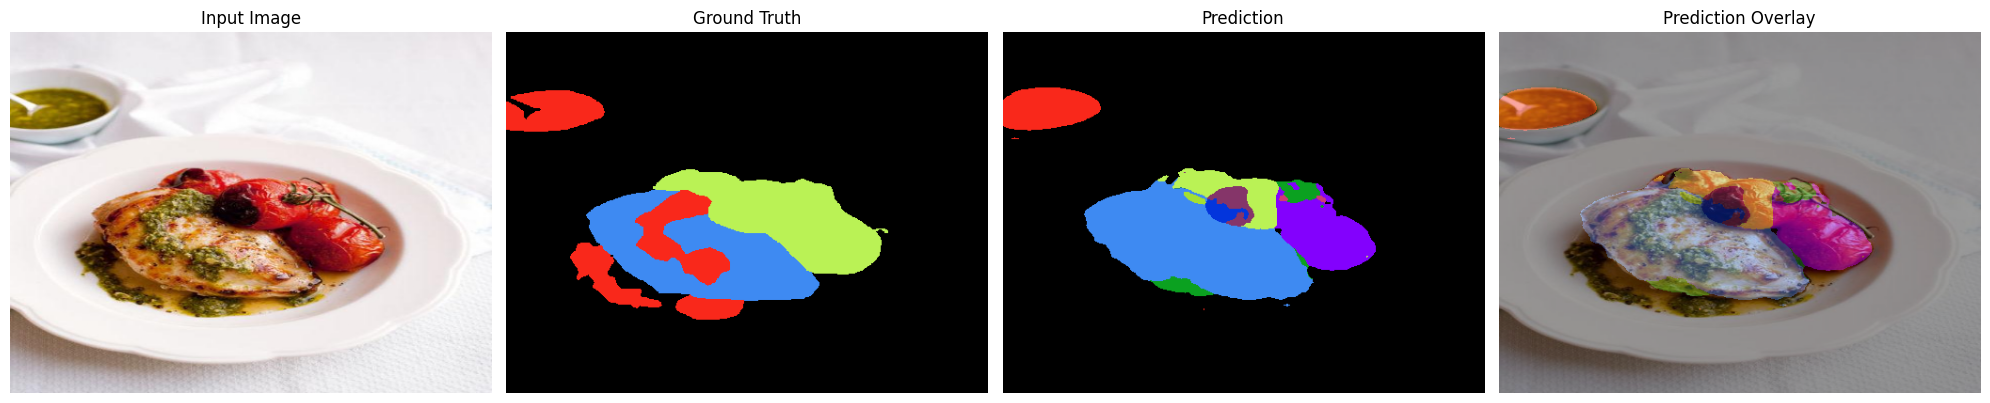


--- Validation Sample 200 ---
Sample mIoU: 0.1988
Predicted classes: ['egg', 'steak', 'pork', 'chicken duck', 'fish', 'potato', 'spring onion', 'lettuce', 'carrot', 'cilantro mint', 'French beans']


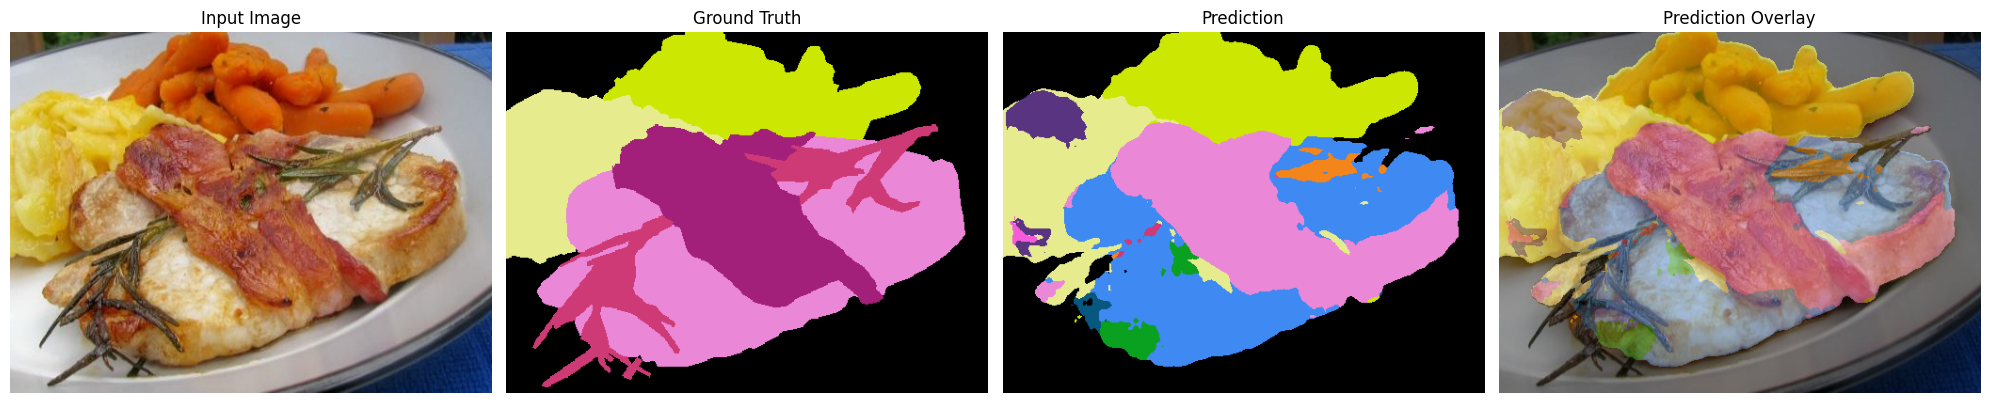


--- Validation Sample 500 ---
Sample mIoU: 0.2336
Predicted classes: ['ice cream', 'cake', 'strawberry', 'cherry', 'raspberry', 'orange', 'bread']


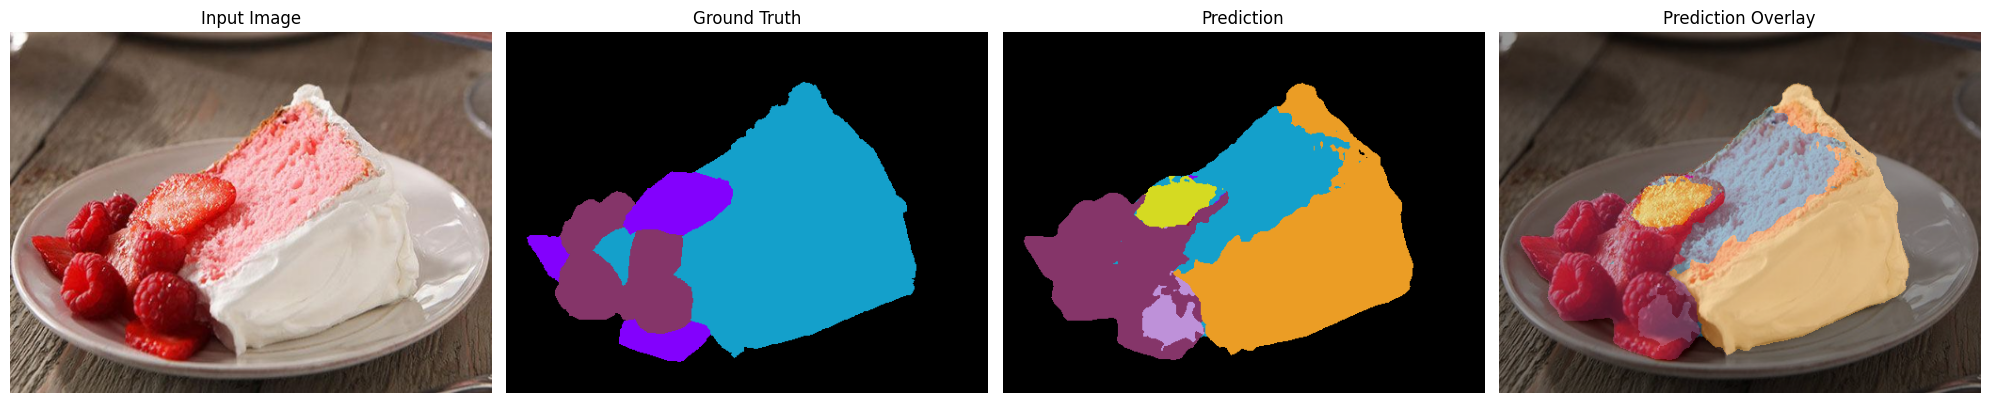

In [27]:
# Visualize predictions on validation samples
for idx in [0, 50, 100, 200, 500]:
    print(f"\n--- Validation Sample {idx} ---")
    visualize_prediction(model, val_dataset, idx, device)

In [28]:
# Per-class IoU analysis
print("\nCalculating per-class IoU...")

class_intersection = torch.zeros(NUM_CLASSES)
class_union = torch.zeros(NUM_CLASSES)

model.eval()
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating per-class"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        
        for cls in range(NUM_CLASSES):
            pred_cls = (preds == cls)
            target_cls = (masks == cls)
            
            class_intersection[cls] += (pred_cls & target_cls).sum()
            class_union[cls] += (pred_cls | target_cls).sum()

# Calculate IoU per class
class_iou = class_intersection / (class_union + 1e-8)

# Print top and bottom classes
print("\nTop 10 classes by IoU:")
sorted_iou = sorted(enumerate(class_iou.tolist()), key=lambda x: x[1], reverse=True)
for cls_id, iou in sorted_iou[:10]:
    if iou > 0:
        print(f"  {FOODSEG103_CLASSES[cls_id]:25s}: {iou:.4f}")

print("\nBottom 10 classes by IoU (non-zero):")
for cls_id, iou in sorted_iou[-10:]:
    if iou > 0:
        print(f"  {FOODSEG103_CLASSES[cls_id]:25s}: {iou:.4f}")


Calculating per-class IoU...


Evaluating per-class:   0%|          | 0/267 [00:00<?, ?it/s]


Top 10 classes by IoU:
  background               : 0.9358
  broccoli                 : 0.8639
  corn                     : 0.8307
  carrot                   : 0.7919
  strawberry               : 0.7909
  banana                   : 0.7789
  green beans              : 0.7782
  celery stick             : 0.7139
  asparagus                : 0.7066
  cauliflower              : 0.7042

Bottom 10 classes by IoU (non-zero):
  melon                    : 0.0414
  eggplant                 : 0.0157
  other ingredients        : 0.0147


---
## 8. Save & Export

In [29]:
# Save final model with all metadata
final_save_path = os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_{ENCODER}_{EPOCHS}epochs.pth')

torch.save({
    'model_state_dict': model.state_dict(),
    'model_name': MODEL_NAME,
    'encoder': ENCODER,
    'num_classes': NUM_CLASSES,
    'img_width': IMG_WIDTH,
    'img_height': IMG_HEIGHT,
    'class_names': FOODSEG103_CLASSES,
    'best_miou': best_miou,
    'training_epochs': EPOCHS,
}, final_save_path)

print(f"✅ Final model saved to: {final_save_path}")
print(f"   File size: {os.path.getsize(final_save_path) / 1e6:.1f} MB")

✅ Final model saved to: ./foodseg_checkpoints/MiT_mit_b3_100epochs/MiT_mit_b3_100epochs.pth
   File size: 181.3 MB


In [30]:
# Optional: Export to ONNX for faster inference
EXPORT_ONNX = True  # Set to True to export

if EXPORT_ONNX:
    onnx_path = os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_{ENCODER}_{EPOCHS}epochs.onnx')
    
    dummy_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).to(device)
    
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        input_names=['image'],
        output_names=['segmentation'],
        dynamic_axes={
            'image': {0: 'batch_size'},
            'segmentation': {0: 'batch_size'}
        },
        opset_version=12
    )
    
    print(f"✅ ONNX model exported to: {onnx_path}")

/tmp/ipykernel_89702/1533317523.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1222 20:18:38.867000 89702 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/home/roylim/anaconda3/envs/sam3/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/roylim/anaconda3/envs/sam3/lib/python3.12/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, targe

Applied 102 of general pattern rewrite rules.
✅ ONNX model exported to: ./foodseg_checkpoints/MiT_mit_b3_100epochs/MiT_mit_b3_100epochs.onnx


---
## 9. Integration with SAM3

Now you can use this trained model with SAM3 for the FoodSAM approach.

In [ ]:
class FoodSegLabeler:
    """Use trained model to label SAM3 masks."""
    
    def __init__(self, model_path, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self._load_model(model_path)
    
    def _load_model(self, model_path):
        """Load trained model."""
        import segmentation_models_pytorch as smp
        
        checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
        
        self.model = smp.DeepLabV3Plus(
            encoder_name=checkpoint['encoder'],
            encoder_weights=None,
            in_channels=3,
            classes=checkpoint['num_classes'],
        )
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model = self.model.to(self.device)
        self.model.eval()
        
        self.img_width = checkpoint.get('img_width', 512)
        self.img_height = checkpoint.get('img_height', 384)
        self.class_names = checkpoint.get('class_names', FOODSEG103_CLASSES)
        
        print(f"✅ FoodSeg model loaded (mIoU: {checkpoint.get('best_miou', 'N/A')})")
    
    def get_semantic_mask(self, image):
        """Get semantic segmentation for an image."""
        from PIL import Image as PILImage
        
        # Handle PIL Image
        if isinstance(image, PILImage.Image):
            orig_w, orig_h = image.size
            img_resized = image.resize((self.img_width, self.img_height), PILImage.BILINEAR)
            img_array = np.array(img_resized).astype(np.float32) / 255.0
        else:
            orig_h, orig_w = image.shape[:2]
            img_resized = np.array(PILImage.fromarray(image).resize((self.img_width, self.img_height)))
            img_array = img_resized.astype(np.float32) / 255.0
        
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            output = self.model(img_tensor)
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
        
        # Resize back
        from PIL import Image as PILImage
        pred_resized = np.array(PILImage.fromarray(pred.astype(np.uint8)).resize(
            (orig_w, orig_h), PILImage.NEAREST))
        
        return pred_resized
    
    def label_mask(self, semantic_mask, sam_mask, threshold=0.5):
        """
        Label a SAM mask using semantic segmentation.
        Returns: (label, confidence, top_predictions)
        """
        mask_bool = sam_mask > 0
        if not mask_bool.any():
            return ("background", 0.0, [])
        
        masked_semantics = semantic_mask[mask_bool]
        unique_classes, counts = np.unique(masked_semantics, return_counts=True)
        
        sorted_indices = np.argsort(counts)[::-1]
        total_pixels = len(masked_semantics)
        
        top_predictions = []
        for idx in sorted_indices[:3]:
            class_id = unique_classes[idx]
            confidence = counts[idx] / total_pixels
            class_name = self.class_names[class_id] if class_id < len(self.class_names) else f"class_{class_id}"
            top_predictions.append((class_name, confidence))
        
        primary_class_id = unique_classes[sorted_indices[0]]
        primary_confidence = counts[sorted_indices[0]] / total_pixels
        primary_label = self.class_names[primary_class_id] if primary_class_id < len(self.class_names) else f"class_{primary_class_id}"
        
        return (primary_label, primary_confidence, top_predictions)

✅ FoodSeg model loaded (mIoU: 0.2876071178776005)


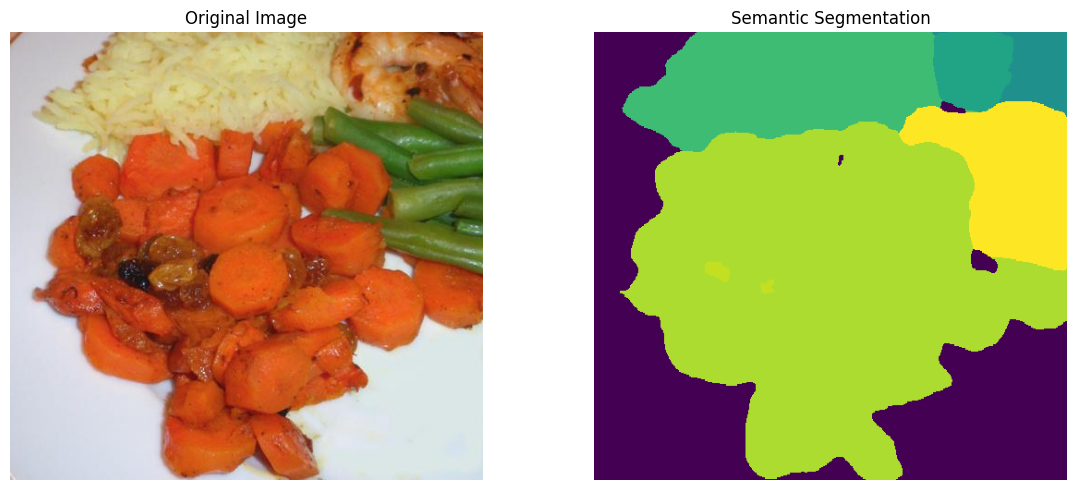

Detected classes:
  - chicken duck
  - shrimp
  - rice
  - potato
  - carrot
  - broccoli
  - French beans


In [ ]:
# Example usage with trained model
labeler = FoodSegLabeler(os.path.join(OUTPUT_DIR, 'best_model.pth'))

# Test on a validation image
test_sample = dataset['validation'][0]
test_image = test_sample['image']

# Get semantic mask
semantic_mask = labeler.get_semantic_mask(test_image)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(test_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(semantic_mask)
axes[1].set_title('Semantic Segmentation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print detected classes
unique_classes = np.unique(semantic_mask)
print("Detected classes:")
for cls in unique_classes:
    if cls != 0:  # Skip background
        print(f"  - {FOODSEG103_CLASSES[cls]}")

In [ ]:
# Example: Label a SAM-like mask (simulated)
# In practice, this would come from SAM3

# Create a fake "SAM mask" by thresholding the semantic mask
# (In real use, this would be a SAM3 output)
fake_sam_mask = (semantic_mask == 66).astype(np.uint8)  # Rice class

if fake_sam_mask.any():
    label, confidence, top_preds = labeler.label_mask(semantic_mask, fake_sam_mask)
    print(f"\nMask label: {label} (confidence: {confidence:.2%})")
    print(f"Top predictions: {top_preds}")
else:
    print("No pixels in test mask")


Mask label: rice (confidence: 100.00%)
Top predictions: [('rice', np.float64(1.0))]


---
## 🎉 Done!

Your trained FoodSeg103 model is saved in `./foodseg_checkpoints/`.

### Next Steps:

1. **Use with SAM3**: Import `FoodSegLabeler` and use it to label SAM3 masks
2. **Improve accuracy**: Train longer, try different encoders (efficientnet-b4, mit_b3)
3. **Deploy**: Export to ONNX for faster inference

### Files created:
- `best_model.pth` - Best model checkpoint
- `foodseg103_final.pth` - Final model with metadata
- `training_history.png` - Training curves